# Kelly Skewness of the Trimmed PCE Price-Change Distribution

This notebook computes Kelly skewness for the monthly distribution of PCE component price changes using the 178 components listed in `Trimmed_Mean_Components.xlsx`.

The Dallas Fed article motivating the calculation defines:

\[
\text{Kelly skewness} = \frac{P90 + P10 - 2 \times P50}{P90 - P10}
\]

where `P10`, `P50`, and `P90` are weighted percentiles of the one-month, non-annualized component price-change distribution. The notebook pulls BEA underlying-detail tables `U20404`, `U20405`, and `U20406`, constructs Dallas Fed-style monthly expenditure weights, and charts monthly Kelly skewness plus its 12-month rolling average from 1980 onward.

Source article: https://www.dallasfed.org/research/economics/2026/0416

In [1]:
from __future__ import annotations

import json
import math
import os
import re
import time
import urllib.parse
import urllib.request
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

## Configuration

The chart starts in 1980. The BEA pull starts in 1979 so January 1980 price changes and the initial rolling average have the needed prior observations.

In [2]:
BASE_DIR = Path.cwd()
COMPONENT_FILE = BASE_DIR / "Trimmed_Mean_Components.xlsx"
CACHE_DIR = BASE_DIR / "cache" / "kelly_skewness"
OUTPUT_DIR = BASE_DIR / "outputs"

BEA_API_URL = "https://apps.bea.gov/api/data"
BEA_DATASET = "NIUnderlyingDetail"
BEA_TABLES = {
    "prices": "U20404",
    "nominal": "U20405",
    "real": "U20406",
}

START_YEAR = 1979
END_YEAR = date.today().year
FIRST_CHART_DATE = pd.Timestamp("1980-01-01")

PERCENTILES = (10, 50, 90)
ROLLING_WINDOW = 12

COMPONENT_BREAKS = [
    {
        "aggregate_line": 156,
        "child_lines": [157, 158],
        "start_date": pd.Timestamp("2002-01-01"),
        "note": "Post-2001 values are split from BEA line 156 using December 2001 nominal shares.",
    }
]
EXTRA_BEA_LINES = sorted({item["aggregate_line"] for item in COMPONENT_BREAKS})

## BEA and Data Helpers

In [3]:
class BEANoDataError(RuntimeError):
    pass


def read_bea_api_key() -> str:
    env_key = os.environ.get("BEA_API_KEY", "").strip()
    if env_key:
        return env_key

    keys_file = BASE_DIR / "API Keys.txt"
    if keys_file.exists():
        for line in keys_file.read_text(encoding="utf-8", errors="ignore").splitlines():
            match = re.match(r"^\s*BEA\s*:\s*(.+?)\s*$", line, flags=re.IGNORECASE)
            if match:
                return match.group(1).strip()

    raise RuntimeError(
        "No BEA API key found. Set BEA_API_KEY or add a local API Keys.txt line like 'BEA: <key>'."
    )


def http_get_json(url: str, params: dict[str, object], timeout: int = 90) -> dict:
    request_url = f"{url}?{urllib.parse.urlencode(params)}"
    request = urllib.request.Request(
        request_url,
        headers={"User-Agent": "kelly-skewness-trimmed-pce/1.0"},
    )
    with urllib.request.urlopen(request, timeout=timeout) as response:
        payload = response.read().decode("utf-8-sig", errors="replace")
    return json.loads(payload)


def bea_get_json(params: dict[str, object]) -> dict:
    payload = dict(params)
    payload.setdefault("UserID", read_bea_api_key())
    payload.setdefault("ResultFormat", "JSON")

    data = http_get_json(BEA_API_URL, payload)
    error = data.get("BEAAPI", {}).get("Error")
    if error:
        code = str(error.get("APIErrorCode", ""))
        detail = str(error.get("ErrorDetail", {}).get("Description", ""))
        description = str(error.get("APIErrorDescription", ""))
        if code == "201" and "No data exists" in f"{description} {detail}":
            raise BEANoDataError(f"BEA has no data for parameters: {params}")
        raise RuntimeError(f"BEA API error: {error}")
    return data


def parse_bea_period(value: object) -> pd.Timestamp:
    match = re.match(r"^(\d{4})M(\d{1,2})$", str(value).strip())
    if not match:
        raise ValueError(f"Unsupported BEA TimePeriod: {value!r}")
    return pd.Timestamp(year=int(match.group(1)), month=int(match.group(2)), day=1)


def parse_data_value(value: object) -> float:
    text = str(value).strip().replace(",", "")
    if text in {"", "(NA)", "NA", "N/A", "#N/A", "..."}:
        return np.nan
    return float(text)

## Load Components and Pull BEA Tables

In [4]:
def load_components(path: Path = COMPONENT_FILE) -> pd.DataFrame:
    components = pd.read_excel(path)
    expected = {"Line Item", "Description", "Code"}
    missing = expected.difference(components.columns)
    if missing:
        raise ValueError(f"Component workbook is missing columns: {sorted(missing)}")

    components = components.rename(
        columns={"Line Item": "line_item", "Description": "description", "Code": "code"}
    )
    components["line_item"] = components["line_item"].astype(int)
    components["description"] = components["description"].astype(str).str.strip()
    components["code"] = components["code"].astype(str).str.strip()
    components = components.sort_values("line_item").reset_index(drop=True)

    checks = {
        "rows": len(components),
        "line_items": components["line_item"].nunique(),
        "codes": components["code"].nunique(),
    }
    if any(value != 178 for value in checks.values()):
        raise ValueError(f"Expected 178 unique components, got {checks}")
    return components


def pull_bea_table_by_year(
    table_name: str,
    start_year: int = START_YEAR,
    end_year: int = END_YEAR,
    use_cache: bool = True,
) -> pd.DataFrame:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / f"{table_name}_{start_year}_{end_year}.csv"
    if use_cache and cache_path.exists():
        return pd.read_csv(cache_path)

    frames: list[pd.DataFrame] = []
    for year in range(start_year, end_year + 1):
        params = {
            "method": "GetData",
            "DataSetName": BEA_DATASET,
            "TableName": table_name,
            "Frequency": "M",
            "Year": str(year),
        }
        try:
            payload = bea_get_json(params)
        except BEANoDataError:
            print(f"{table_name} {year}: no monthly data, skipped")
            continue

        data = payload.get("BEAAPI", {}).get("Results", {}).get("Data")
        if data is None:
            raise RuntimeError(f"BEA response for {table_name} {year} did not include Results.Data")
        if isinstance(data, dict):
            data = [data]

        frame = pd.DataFrame(data)
        frame["requested_year"] = year
        frames.append(frame)
        time.sleep(0.1)

    if not frames:
        raise RuntimeError(f"No BEA data returned for {table_name}")

    result = pd.concat(frames, ignore_index=True)
    result.to_csv(cache_path, index=False)
    return result


def clean_bea_table(
    raw: pd.DataFrame,
    components: pd.DataFrame,
    table_name: str,
    require_all_components: bool = True,
    extra_lines: list[int] | None = None,
) -> pd.DataFrame:
    required = {"LineNumber", "TimePeriod", "DataValue"}
    missing = required.difference(raw.columns)
    if missing:
        raise ValueError(f"{table_name} is missing columns: {sorted(missing)}")

    component_lines = components["line_item"].tolist()
    line_order = component_lines + [line for line in (extra_lines or []) if line not in component_lines]

    df = raw.copy()
    df["line_item"] = pd.to_numeric(df["LineNumber"], errors="coerce").astype("Int64")
    df["date"] = df["TimePeriod"].map(parse_bea_period)
    df["value"] = df["DataValue"].map(parse_data_value)
    df = df[df["line_item"].isin(line_order)].copy()

    present = set(df["line_item"].dropna().astype(int).unique())
    missing_lines = sorted(set(component_lines).difference(present))
    if missing_lines and require_all_components:
        raise ValueError(f"{table_name} is missing {len(missing_lines)} component line items")
    if missing_lines:
        print(f"{table_name}: {len(missing_lines)} component lines absent; fallback will be used where possible")

    matrix = (
        df.pivot_table(index="date", columns="line_item", values="value", aggfunc="first")
        .sort_index()
        .reindex(columns=line_order)
    )
    matrix.columns = matrix.columns.astype(int)
    return matrix.dropna(how="all")


def pull_all_bea_matrices(components: pd.DataFrame) -> dict[str, pd.DataFrame]:
    matrices: dict[str, pd.DataFrame] = {}
    for label, table_name in BEA_TABLES.items():
        print(f"Pulling BEA table {table_name} ({label}) for {START_YEAR}-{END_YEAR} ...")
        raw = pull_bea_table_by_year(table_name)
        matrices[label] = clean_bea_table(
            raw,
            components,
            table_name,
            require_all_components=(label != "real"),
            extra_lines=EXTRA_BEA_LINES,
        )
        print(f"  {table_name}: {matrices[label].index.min():%Y-%m} to {matrices[label].index.max():%Y-%m}")
    return matrices

## Construct Dallas Fed-Style Weights

In [5]:
def _split_ratios_from_last_child_observation(
    matrix: pd.DataFrame,
    child_lines: list[int],
    before_date: pd.Timestamp,
) -> pd.Series:
    children = matrix.reindex(columns=child_lines)
    valid = children.loc[children.index < before_date].notna().all(axis=1)
    valid &= children.loc[children.index < before_date].sum(axis=1) > 0
    if not valid.any():
        return pd.Series(1.0 / len(child_lines), index=child_lines)

    last_date = valid[valid].index.max()
    values = children.loc[last_date]
    return values / values.sum()


def apply_component_break_adjustments(
    matrices: dict[str, pd.DataFrame],
    components: pd.DataFrame,
) -> dict[str, pd.DataFrame]:
    adjusted = {label: matrix.copy() for label, matrix in matrices.items()}

    for item in COMPONENT_BREAKS:
        aggregate_line = item["aggregate_line"]
        child_lines = item["child_lines"]
        start_date = item["start_date"]

        if aggregate_line not in adjusted["nominal"].columns:
            continue

        split_ratios = _split_ratios_from_last_child_observation(
            adjusted["nominal"], child_lines, start_date
        )

        for child_line in child_lines:
            for label in ["prices"]:
                matrix = adjusted[label]
                if aggregate_line not in matrix.columns or child_line not in matrix.columns:
                    continue
                fill_mask = (
                    matrix[child_line].isna()
                    & matrix[aggregate_line].notna()
                    & (matrix.index >= start_date)
                )
                matrix.loc[fill_mask, child_line] = matrix.loc[fill_mask, aggregate_line]

            for label in ["nominal", "real"]:
                matrix = adjusted[label]
                if aggregate_line not in matrix.columns or child_line not in matrix.columns:
                    continue
                fill_mask = (
                    matrix[child_line].isna()
                    & matrix[aggregate_line].notna()
                    & (matrix.index >= start_date)
                )
                matrix.loc[fill_mask, child_line] = (
                    matrix.loc[fill_mask, aggregate_line] * float(split_ratios.loc[child_line])
                )

        for label, matrix in adjusted.items():
            if aggregate_line in matrix.columns:
                adjusted[label] = matrix.drop(columns=[aggregate_line])

    component_lines = components["line_item"].tolist()
    return {label: matrix.reindex(columns=component_lines) for label, matrix in adjusted.items()}


def build_quantity_matrix(matrices: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    price = matrices["prices"]
    real = matrices["real"]
    nominal = matrices["nominal"]

    common_index = price.index.intersection(nominal.index)
    common_columns = price.columns.intersection(nominal.columns)

    price = price.loc[common_index, common_columns].sort_index()
    real = real.reindex(index=common_index, columns=common_columns).sort_index()
    nominal = nominal.loc[common_index, common_columns].sort_index()

    fallback_quantity = nominal / price
    missing_real = real.isna() & fallback_quantity.notna()
    quantity = real.where(~missing_real, fallback_quantity)

    fallback_summary = pd.DataFrame(
        {
            "fallback_quantity_cells": [int(missing_real.sum().sum())],
            "total_quantity_cells": [int(quantity.size)],
        }
    )
    return quantity, fallback_summary


def restrict_to_complete_months(price: pd.DataFrame, quantity: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    common_index = price.index.intersection(quantity.index)
    common_columns = price.columns.intersection(quantity.columns)
    price = price.loc[common_index, common_columns].sort_index()
    quantity = quantity.loc[common_index, common_columns].sort_index()

    complete = price.notna().all(axis=1) & quantity.notna().all(axis=1)
    price = price.loc[complete]
    quantity = quantity.loc[complete]

    if price.index.min() > pd.Timestamp("1979-01-01"):
        raise ValueError("Complete BEA data start after 1979-01, so January 1980 rates cannot be built.")
    if pd.Timestamp("1980-01-01") not in price.index:
        raise ValueError("Complete BEA data do not include January 1980.")
    return price, quantity


def compute_price_changes_and_weights(
    price: pd.DataFrame,
    quantity: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    price_changes = price.pct_change().iloc[1:]

    p_lag = price.shift(1).iloc[1:].to_numpy(dtype=float)
    q_current = quantity.iloc[1:].to_numpy(dtype=float)
    q_lag = quantity.shift(1).iloc[1:].to_numpy(dtype=float)

    weight_1 = q_current * p_lag
    weight_1 = weight_1 / weight_1.sum(axis=1, keepdims=True)

    weight_2 = q_lag * p_lag
    weight_2 = weight_2 / weight_2.sum(axis=1, keepdims=True)

    weights = 0.5 * weight_1 + 0.5 * weight_2
    weights = weights / weights.sum(axis=1, keepdims=True)
    weights = pd.DataFrame(weights, index=price_changes.index, columns=price.columns)

    if not np.isfinite(price_changes.to_numpy()).all():
        raise ValueError("Non-finite monthly price changes encountered.")
    if not np.isfinite(weights.to_numpy()).all():
        raise ValueError("Non-finite weights encountered.")
    return price_changes, weights

## Kelly Skewness

In [6]:
def weighted_percentile(
    values: pd.Series,
    weights: pd.Series,
    percentiles: tuple[int, ...] = PERCENTILES,
) -> dict[int, float]:
    values = values.astype(float)
    weights = weights.reindex(values.index).astype(float)

    valid = values.notna() & weights.notna() & (weights > 0)
    values = values.loc[valid]
    weights = weights.loc[valid]
    if values.empty:
        return {p: np.nan for p in percentiles}

    order = np.lexsort((values.index.astype(int), values.to_numpy()))
    sorted_values = values.to_numpy()[order]
    sorted_weights = weights.to_numpy()[order]
    sorted_weights = sorted_weights / sorted_weights.sum()
    cumulative = np.cumsum(sorted_weights)

    output: dict[int, float] = {}
    for percentile in percentiles:
        threshold = percentile / 100.0
        idx = int(np.searchsorted(cumulative, threshold, side="left"))
        idx = min(idx, len(sorted_values) - 1)
        output[percentile] = float(sorted_values[idx])
    return output


def compute_kelly_skewness(
    price_changes: pd.DataFrame,
    weights: pd.DataFrame,
) -> pd.DataFrame:
    records: list[dict[str, object]] = []

    for month in price_changes.index:
        pct = weighted_percentile(price_changes.loc[month] * 100.0, weights.loc[month])
        p10, p50, p90 = pct[10], pct[50], pct[90]
        denominator = p90 - p10
        skewness = np.nan if math.isclose(denominator, 0.0) else (p90 + p10 - 2.0 * p50) / denominator
        records.append(
            {
                "date": month,
                "period": month.strftime("%Y-%m"),
                "p10": p10,
                "p50": p50,
                "p90": p90,
                "kelly_skewness": skewness,
            }
        )

    skewness = pd.DataFrame(records).set_index("date").sort_index()
    skewness["kelly_skewness_12m_avg"] = (
        skewness["kelly_skewness"].rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean()
    )
    return skewness

## Run Calculation

In [7]:
components = load_components()
matrices = pull_all_bea_matrices(components)
matrices = apply_component_break_adjustments(matrices, components)

quantity, fallback_summary = build_quantity_matrix(matrices)
price, quantity = restrict_to_complete_months(matrices["prices"], quantity)
price_changes, weights = compute_price_changes_and_weights(price, quantity)
skewness_full = compute_kelly_skewness(price_changes, weights)
skewness = skewness_full.loc[FIRST_CHART_DATE:].copy()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_csv = OUTPUT_DIR / "kelly_skewness_trimmed_pce.csv"
skewness.reset_index().to_csv(output_csv, index=False)

summary = pd.DataFrame(
    {
        "metric": [
            "component_count",
            "first_chart_period",
            "last_chart_period",
            "output_csv",
            "fallback_quantity_cells",
            "total_quantity_cells",
            "max_weight_sum_error",
        ],
        "value": [
            len(components),
            skewness.index.min().strftime("%Y-%m"),
            skewness.index.max().strftime("%Y-%m"),
            str(output_csv),
            int(fallback_summary.loc[0, "fallback_quantity_cells"]),
            int(fallback_summary.loc[0, "total_quantity_cells"]),
            float((weights.sum(axis=1) - 1.0).abs().max()),
        ],
    }
)
display(summary)
display(skewness.tail(12))

Pulling BEA table U20404 (prices) for 1979-2026 ...


C:\Users\abour\AppData\Local\Temp\ipykernel_15420\3684234199.py:35: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(cache_path)


  U20404: 1979-01 to 2026-04
Pulling BEA table U20405 (nominal) for 1979-2026 ...


  U20405: 1979-01 to 2026-04
Pulling BEA table U20406 (real) for 1979-2026 ...


U20406: 2 component lines absent; fallback will be used where possible
  U20406: 2007-01 to 2026-04


,metric,value
0,component_count,178
1,first_chart_period,1980-01
2,last_chart_period,2026-04
3,output_csv,C:\Users\abour\OneDrive\Economic Research\Infl...
4,fallback_quantity_cells,59808
5,total_quantity_cells,101104
6,max_weight_sum_error,0.0


,period,p10,p50,p90,kelly_skewness,kelly_skewness_12m_avg
date,,,,,,
2025-05-01,2025-05,-0.557721,0.219835,0.899169,-0.067419,-0.131120
2025-06-01,2025-06,-0.361393,0.301827,1.190853,0.145470,-0.104487
2025-07-01,2025-07,-0.534511,0.190934,1.017571,0.065198,-0.106692
2025-08-01,2025-08,-0.460856,0.340166,1.027048,-0.076712,-0.085043
2025-09-01,2025-09,-0.503262,0.136723,0.947239,0.117566,-0.060674
2025-10-01,2025-10,-0.425614,0.160590,0.892509,0.110548,-0.051938
2025-11-01,2025-11,-0.364508,0.161745,0.764792,0.068002,-0.021618
2025-12-01,2025-12,-0.355137,0.270868,0.902834,0.004739,0.005253
2026-01-01,2026-01,-0.390115,0.218631,1.601673,0.388744,0.012583


## Chart

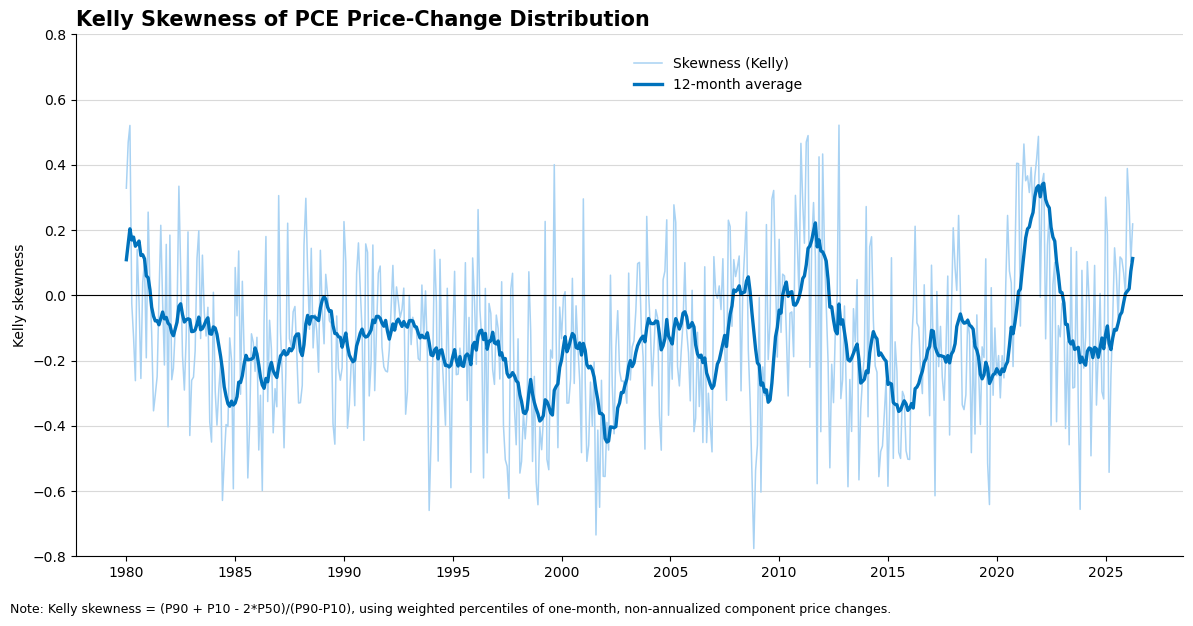

WindowsPath('C:/Users/abour/OneDrive/Economic Research/Inflation/Trimmed Mean PCE/outputs/kelly_skewness_trimmed_pce.png')

In [8]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    skewness.index,
    skewness["kelly_skewness"],
    color="#A8D2F3",
    linewidth=1.1,
    label="Skewness (Kelly)",
)
ax.plot(
    skewness.index,
    skewness["kelly_skewness_12m_avg"],
    color="#0072BC",
    linewidth=2.4,
    label="12-month average",
)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Kelly Skewness of PCE Price-Change Distribution", fontsize=15, weight="bold", loc="left")
ax.set_ylabel("Kelly skewness")
ax.set_xlabel("")
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.58, 0.98))

max_abs = float(np.nanmax(np.abs(skewness[["kelly_skewness", "kelly_skewness_12m_avg"]].to_numpy())))
y_bound = max(0.8, math.ceil(max_abs * 5) / 5)
ax.set_ylim(-y_bound, y_bound)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.text(
    0.01,
    -0.03,
    "Note: Kelly skewness = (P90 + P10 - 2*P50)/(P90-P10), using weighted percentiles of one-month, non-annualized component price changes.",
    fontsize=9,
)
fig.tight_layout()

chart_path = OUTPUT_DIR / "kelly_skewness_trimmed_pce.png"
fig.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

chart_path